# Parsing Djinni vacancies and analyzing skills

this notebook is created based on previous https://github.com/Maxstef/data-loves-ml-for-people-course/blob/main/notebooks/6_0_parse_analyse_text/DOU%20Vacancies%20Parsing%20and%20Analysis.ipynb


In [ ]:
# !pip install selenium chromedriver_autoinstaller -q

In [1]:
from selenium import webdriver
from bs4 import BeautifulSoup
import pandas as pd
import time
import requests
from tqdm import tqdm

import chromedriver_autoinstaller as chromedriver
chromedriver.install()

from selenium.webdriver.common.by import By

## Step 1 - collect all vacancies links

1) Open djinni search result page
2) Collect links to each separate vacancy
3) Go to next search result page if exsting
4) Repeate 2

In [50]:
# replace it if needed
search_url = 'https://djinni.co/jobs/?search_type=basic-search&primary_keyword=Data%20Science&primary_keyword=ML%20AI'

In [51]:
driver = webdriver.Chrome()

driver.get(search_url)

Djinni has pagination instead of "Load more"

In [52]:
PAGE_COUNT_LIMIT = 50
index = 0
project_hrefs = []

while True:
    try:
        # collect link on current page
        curr_content = driver.page_source
        curr_content = BeautifulSoup(curr_content)
        curr_vac_list = curr_content.find_all('a',href=True, attrs={'class':'job_item__header-link'})
        curr_project_hrefs = [i['href'] for i in curr_vac_list]

        project_hrefs.extend(curr_project_hrefs)

        # check next page element exist and click it
        pagination_last_element = driver.find_element(By.CSS_SELECTOR, '.page-item:last-child .page-link')
        pagination_next_element = driver.find_elements(By.CSS_SELECTOR, '.page-item:last-child .page-link .bi-chevron-right')
        if len(pagination_next_element) > 0:
            pagination_last_element.click()
        else:
            raise ValueError("no next element END")

        # avoid too many vacancies or infinite loop
        index += 1
        if index >= PAGE_COUNT_LIMIT:
            raise ValueError("No infinite loop END")
        
        # wait till page loads
        time.sleep(3)
    except Exception as ex:
        print(ex)
        print('End.')
        break

Message: element click intercepted: Element <a class="page-link" href="#" tabindex="-1" aria-disabled="True">...</a> is not clickable at point (740, 853). Other element would receive the click: <li class="page-item disabled">...</li>
  (Session info: chrome=148.0.7778.168); For documentation on this error, please visit: https://www.selenium.dev/documentation/webdriver/troubleshooting/errors#elementclickinterceptedexception
Stacktrace:
0   chromedriver                        0x0000000105522584 cxxbridge1$str$ptr + 3225716
1   chromedriver                        0x000000010551a45c cxxbridge1$str$ptr + 3192652
2   chromedriver                        0x0000000104fdb8f4 _RNvCsiKAbIcglKMQ_7___rustc35___rust_no_alloc_shim_is_unstable_v2 + 75152
3   chromedriver                        0x0000000105029614 _RNvCsiKAbIcglKMQ_7___rustc35___rust_no_alloc_shim_is_unstable_v2 + 393904
4   chromedriver                        0x0000000105027e80 _RNvCsiKAbIcglKMQ_7___rustc35___rust_no_alloc_shim_is_unsta

In [53]:
# total number of search result pages collected
index

16

In [54]:
# total number of vacancies collected
len(project_hrefs), project_hrefs[0]

(250, '/jobs/825536-ai-technical-lead/')

In [55]:
driver.close()

## Step 2 - Collect content of each vacancy

* open each page by links collected on step 1
* save link, title and description to vacancies dictionary
* create data frame from collected dictionary

In [56]:
headers={"User-Agent": "HTTPie/3.1.0"}

host = 'https://djinni.co'

In [57]:
vacs = {
    'link': [],
    'name': [],
    'desc': []
}
for link in tqdm(project_hrefs):
    page = requests.get(host + link, headers=headers)
    soup = BeautifulSoup(page.content, "html.parser")
    vacs['link'].append(host + link)
    vacs['name'].append(soup.title.text)
    vacs['desc'].append(soup.select('div.job-post__description')[0].text)
    time.sleep(1)

100%|██████████| 250/250 [05:29<00:00,  1.32s/it]


In [58]:
len(vacs['link'])

250

In [59]:
vacs_df = pd.DataFrame(vacs)
vacs_df.head()

,link,name,desc
0,https://djinni.co/jobs/825536-ai-technical-lead/,AI Technical Lead в 8allocate – Djinni,\nProject: A bootstrapped Israeli startup buil...
1,https://djinni.co/jobs/818644-ai-automation-en...,AI Automation Engineer в MEGOGO – Djinni,"\nМи шукаємо фахівця, який стане драйвером тра..."
2,https://djinni.co/jobs/780935-tech-artist-asse...,"Tech Artist + Assets Manager, who would shape ...",\nThe company is looking for a Tech Artist / A...
3,https://djinni.co/jobs/763034-crm-content-mana...,CRM Content Manager в King Group – Djinni,\nKing Group — сучасна компанія з інноваційним...
4,https://djinni.co/jobs/825506-ai-ml-computer-v...,AI/ML Computer Vision Engineer в Альфа Віжн – ...,\nМи будуємо систему комп'ютерного зору для со...


### Save data frame to csv

In [60]:
vacs_df.to_csv('data/djinni_may_26_science_vacs.csv', index=False)

In [61]:
print(vacs_df.desc.loc[1])


Ми шукаємо фахівця, який стане драйвером трансформації всередині компанії. Твоє завдання - перетворювати ручні процеси на стабільні автоматизовані системи, використовуючи синергію LLM, no-code/low-code інструментів та Python. Це роль про практичні рішення: від швидкого прототипування до впровадження в production. Основні обовʼязки:Побудова Workflow: Проєктування та реалізація багатокрокових automation workflows (переважно в n8n).Інтеграція AI: Впровадження LLM (Gemini, OpenAI, Claude) у бізнес-процеси та розробка інтелектуальних AI-агентів.Prompt Engineering: Оптимізація логіки взаємодії з моделями, робота з prompt chaining та тестування результатів.Кастомна розробка: Написання Python-скриптів для нестандартної логіки та обробки даних там, де no-code потребує підсилення.API та Інтеграції: Побудова надійних зв’язків через REST API та webhooks із CRM, базами даних та внутрішніми системами MEGOGO.Підтримка: Моніторинг, дебаг та оптимізація вже працюючих автоматизацій.Що ми очікуємо:1–2 р

## Step 3 - base WordCloud visualization

In [ ]:
# !pip install wordcloud -q

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from nltk.corpus import stopwords
from wordcloud import WordCloud

In [63]:
vacs_df = pd.read_csv('data/djinni_may_26_science_vacs.csv')

In [64]:
stopwords_ua = pd.read_csv("data/stopwords_ua.txt", header=None, names=['stopwords'])
stopwords_ua = list(stopwords_ua.stopwords)

stopwords_list = stopwords_ua + stopwords.words('english')

stopwords_list[:5], stopwords_list[-5:]

(['а', 'аби', 'абиде', 'абиким', 'абикого'],
 ["you're", 'yours', 'yourself', 'yourselves', "you've"])

In [65]:
text = '\n'.join(vacs_df.desc.tolist())
len(text)

674217

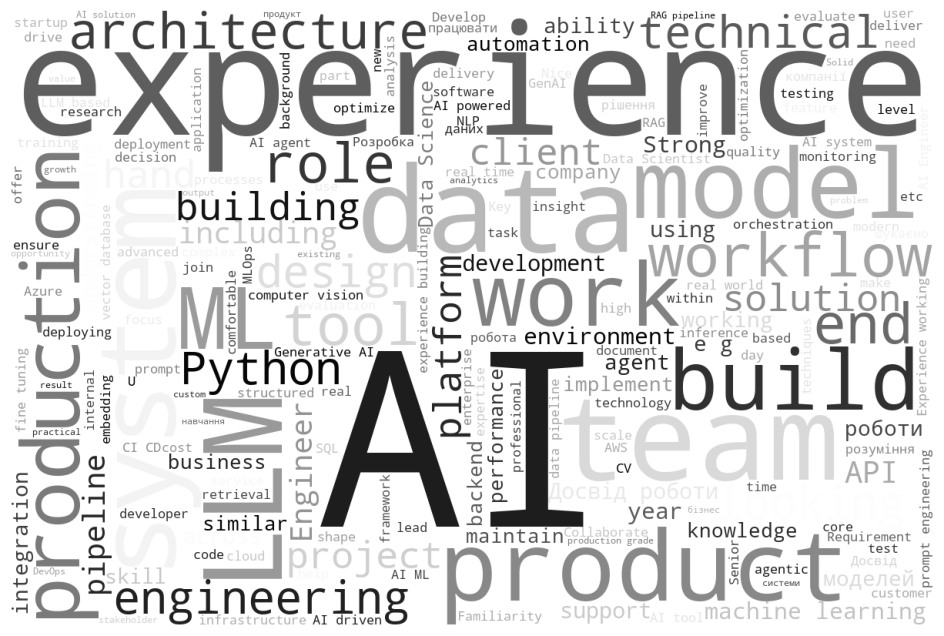

In [66]:
def create_wordcloud(text, stopwords_list, width=1200, height=800, colormap='binary', background_color='white', figsize=(14,8)):
    wc = WordCloud(
        background_color=background_color, 
        colormap = colormap, 
        stopwords = stopwords_list, 
        width = width, 
        height = height).generate(text)
    plt.figure(figsize=figsize)
    plt.axis("off")
    plt.imshow(wc)

create_wordcloud(text, stopwords_list)

## Step 4 - Extract skills with OpenAI API

> Note: This part is billable and `OPENAI_API_KEY` value must be setup in env variables

In [67]:
from openai import OpenAI

client = OpenAI()

In [68]:
openai_model_used = 'gpt-4o-mini'
max_tokens = 4096

def generate_messages(system_content, user_content):
    return [
        {
            "role": "system",
            "content": system_content            
        },
        {
            "role": "user",
            "content":  user_content
        }
    ]

def get_openai_response(messages, temperature=0, max_tokens=max_tokens, top_p=1):
    client = OpenAI()
    return client.chat.completions.create(
        model=openai_model_used,
        messages=messages,
        temperature=temperature,
        # max_tokens=max_tokens,
        top_p=top_p
    )

In [69]:
prompt = """
You are provided with a technical vacancy description either in English or in Ukrainian. 
Extract only skills required for a candidate and the responsibilities. Return the extracted part 
as a plain text as it is provided without changing it.
Vacancy:
{}
"""
system_content = ''

### Smoke test on one sample

In [70]:
response = get_openai_response(
    generate_messages(system_content, prompt.format(vacs_df.desc.loc[0]))
)

In [71]:
response_text = response.model_dump()['choices'][0]['message']['content']
print(response_text)

**Skills Required:**
- 5+ years of hands-on experience building AI systems in production (recent AI, not legacy ML)
- Production experience with LangChain / LangGraph (mandatory)
- Experience with multi-agent orchestration patterns (planner-executor, supervisor, handoff)
- Knowledge of RAG, MCP, embeddings, prompt design, and context management
- Strong Python; JavaScript / Node.js as secondary
- DevOps-capable: CI/CD, Docker, monitoring, logging, DB migrations
- Experience testing non-deterministic LLM systems (evals, golden datasets)
- Experience integrating with SaaS platforms (Salesforce, Google Workspace, Slack, etc.)
- Security best practices: auth/authz, secrets management, OWASP Top 10, LLM-specific risks (prompt injection, tool abuse)
- Awareness of SOC 2 / GDPR
- React / Next.js — advantage (secondary priority)
- Startup mindset: comfortable with ambiguity, end-to-end ownership, fast context-switching

**Responsibilities:**
- Design and build multi-agent systems using LangCha

### Process all vacancies

> Note: Be careful here - this is billable

In [72]:
# process all vacancies

def get_skills(vacancy):
    return get_openai_response(generate_messages(system_content, prompt.format(vacancy)))

vacs_df['skills'] = vacs_df.desc.apply(get_skills)

> Note: having 250 vacancies it run ~30mins

In [73]:
vacs_df['skills_text'] = vacs_df.skills.apply(lambda x: x.model_dump()['choices'][0]['message']['content'])

In [74]:
print(vacs_df['skills_text'].loc[1])

**Основні обовʼязки:**
- Побудова Workflow: Проєктування та реалізація багатокрокових automation workflows (переважно в n8n).
- Інтеграція AI: Впровадження LLM (Gemini, OpenAI, Claude) у бізнес-процеси та розробка інтелектуальних AI-агентів.
- Prompt Engineering: Оптимізація логіки взаємодії з моделями, робота з prompt chaining та тестування результатів.
- Кастомна розробка: Написання Python-скриптів для нестандартної логіки та обробки даних там, де no-code потребує підсилення.
- API та Інтеграції: Побудова надійних зв’язків через REST API та webhooks із CRM, базами даних та внутрішніми системами MEGOGO.
- Підтримка: Моніторинг, дебаг та оптимізація вже працюючих автоматизацій.

**Що ми очікуємо:**
- 1–2 роки досвіду в automation, backend або AI-напрямах.
- Впевнений практичний досвід роботи з n8n (або аналогами).
- Базові або середні знання Python (скрипти, робота з API, базові бібліотеки).
- Глибоке розуміння REST API, webhooks та форматів даних (JSON).
- Практичний досвід роботи з L

### Save enriched data frame to csv

In [75]:
vacs_df.to_csv('data/djinni_may_26_science_vacs_enriched.csv', index=False)

## Step 5 - skills enriched WordCloud visualization

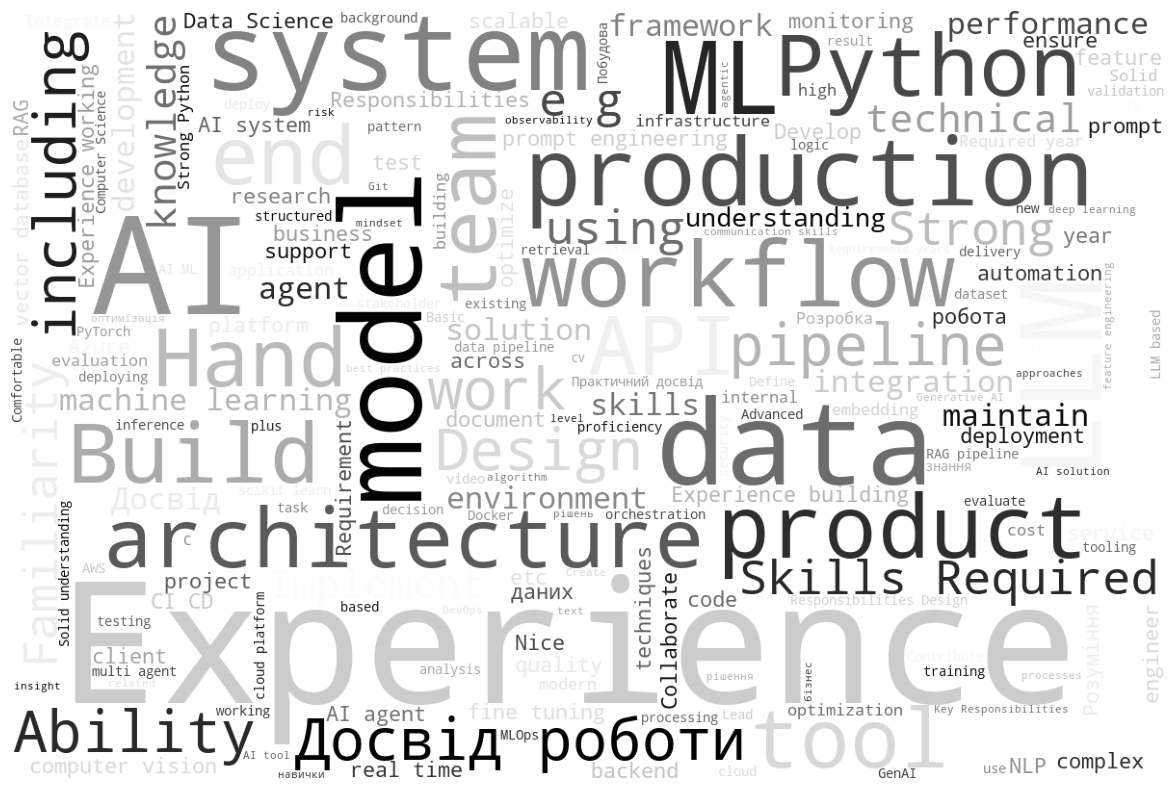

In [76]:
vacs_df = pd.read_csv('data/djinni_may_26_science_vacs_enriched.csv')

text = '\n'.join(vacs_df.skills_text.tolist())
create_wordcloud(text, stopwords_list, figsize=(16,10))

## Extra Stuff - N-grams and other

In [77]:
import nltk
from nltk import word_tokenize
from nltk.util import bigrams
from collections import Counter
import re

nltk.download('punkt') 

def clean_text(text):
    # Remove non-word characters
    text = re.sub(r'\W+', ' ', text).lower()
    # Tokenize text
    tokens = word_tokenize(text)
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    cleaned_tokens = [word for word in tokens if word not in stop_words]
    # Join cleaned tokens back into a string
    return ' '.join(cleaned_tokens)


# re-define text var
text = '\n'.join(vacs_df.skills_text.tolist())

tokens = word_tokenize(clean_text(text.lower()))  # Tokenize and convert to lower case
bigram_list = list(bigrams(tokens))
bigram_freq = Counter(bigram_list)

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/maksymstefanko/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [78]:
bigram_freq_d = dict(bigram_freq)

In [79]:
bigram_freq_d = {' '.join(k):v for k, v in bigram_freq_d.items()}

In [80]:
bigram_df = pd.DataFrame(bigram_freq_d.items(), columns=['bigram', 'freq'])

In [81]:
bigram_df.sort_values(by = 'freq', ascending=False)[:30]

,bigram,freq
266,роботи з,120
265,досвід роботи,113
4,hands experience,110
0,skills required,94
1034,e g,93
1443,machine learning,85
5,experience building,75
193,prompt engineering,68
2047,years experience,66
1837,computer vision,63


In [82]:
vacs_df['contains llm'] = vacs_df.desc.str.lower().apply(lambda x: 'llm' in x or 'generative' in x)
vacs_df['contains neural'] = vacs_df.desc.str.lower().apply(lambda x: 'neural' in x or 'deep' in x)
vacs_df['contains cv'] = vacs_df.desc.str.lower().apply(lambda x: 'computer vision' in x or 'cv' in x)

In [83]:
vacs_df.to_csv('data/djinni_may_26_science_vacs_enriched.csv', index=False)

In [84]:
vacs_df['contains llm'].value_counts()

contains llm
True     145
False    105
Name: count, dtype: int64

In [85]:
vacs_df['contains neural'].value_counts()

contains neural
False    165
True      85
Name: count, dtype: int64

In [86]:
vacs_df['contains cv'].value_counts()

contains cv
False    189
True      61
Name: count, dtype: int64